In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from google.colab import files
uploaded=files.upload()

Saving mall.csv to mall.csv


In [ ]:
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv('mall.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
df.drop(['CustomerID'],axis=1,inplace=True)


KeyError: "['CustomerID'] not found in axis"

In [ ]:

df.rename(columns={'Annual Income (k$)':'annual'},inplace=True)
df.rename(columns={'Spending Score (1-100)':'spend'},inplace=True)
df.head()

,Gender,Age,annual,spend
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler
x=df
scaler=MinMaxScaler()
v=scaler.fit_transform(x)
print(v)

[[1.         0.01923077 0.         0.3877551  0.        ]
 [1.         0.05769231 0.         0.81632653 0.        ]
 [0.         0.03846154 0.00819672 0.05102041 0.33333333]
 [0.         0.09615385 0.00819672 0.7755102  0.33333333]
 [0.         0.25       0.01639344 0.39795918 0.33333333]
 [0.         0.07692308 0.01639344 0.76530612 0.33333333]
 [0.         0.32692308 0.02459016 0.05102041 0.33333333]
 [0.         0.09615385 0.02459016 0.94897959 0.33333333]
 [1.         0.88461538 0.03278689 0.02040816 0.        ]
 [0.         0.23076923 0.03278689 0.7244898  0.33333333]
 [1.         0.94230769 0.03278689 0.13265306 0.        ]
 [0.         0.32692308 0.03278689 1.         0.33333333]
 [0.         0.76923077 0.04098361 0.14285714 0.33333333]
 [0.         0.11538462 0.04098361 0.7755102  0.33333333]
 [1.         0.36538462 0.04098361 0.12244898 0.        ]
 [1.         0.07692308 0.04098361 0.79591837 0.        ]
 [0.         0.32692308 0.04918033 0.34693878 0.33333333]
 [1.         0

In [ ]:
model=DBSCAN(eps=0.5,min_samples=5)
model.fit(v)
y_predict=model.fit_predict(v)
df['cluster']=y_predict
df.head()
y_predict

array([0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0])

In [ ]:
df.head()

,Gender,Age,annual,spend,cluster
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,1
3,0,23,16,77,1
4,0,31,17,40,1


In [ ]:
from sklearn.metrics import silhouette_score
score=silhouette_score(v,y_predict)
score

np.float64(0.5225751423740248)

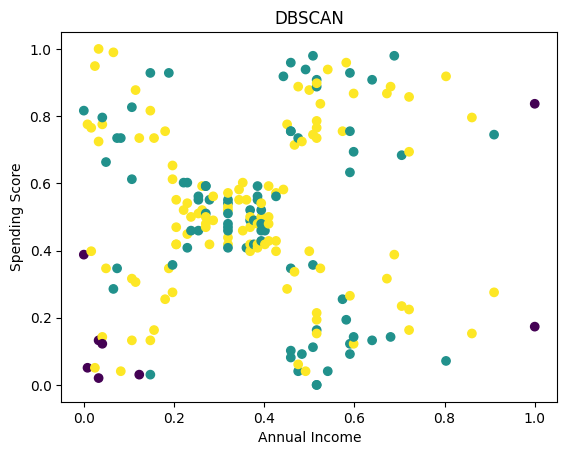

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(v[:,2],v[:,3],c=y_predict)
plt.title("DBSCAN")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


In [ ]:
for eps in [0.3, 0.4, 0.5, 0.6, 0.7]:
    model = DBSCAN(eps=eps, min_samples=3)

    labels = model.fit_predict(v)

    print(eps)

0.3
0.4
0.5
0.6
0.7


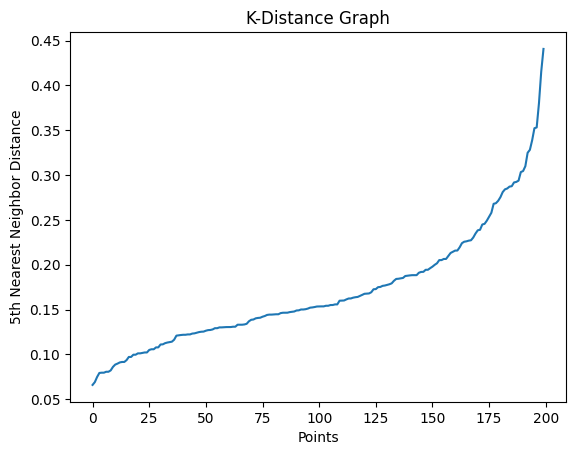

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(v)

distances, indices = neighbors_fit.kneighbors(v)

distances = distances[:, 4]

distances = np.sort(distances)

plt.plot(distances)

plt.xlabel("Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.title("K-Distance Graph")

plt.show()

In [ ]:
p=model.core_sample_indices_
print(p)

[  0   1   3   4   5   6   7   9  10  11  12  13  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128
 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146
 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164
 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197]


In [ ]:
label=model.fit_predict(v)
print(label)

[0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 1
 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1
 0 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0
 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 0 1
 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 1 0 1 1 1 1 0 0 0]


In [ ]:
print(score)

0.5225751423740248
